# JFET Drain and Transfer Characteristics — Complete Analysis
## BSc 3rd Year Physics Practical | Tri-Chandra Multiple Campus, TU Nepal
### Experiment No. 8 | Date: 2082/01/30 (BS)

---

This notebook provides a complete reproducible analysis of the **Junction Field Effect Transistor (JFET)** experiment:
- Drain characteristics: $I_D$ vs $V_{DS}$ at fixed $V_{GS}$
- Transfer characteristics: $I_D$ vs $V_{GS}$ at fixed $V_{DS}$  
- Shockley equation curve fitting
- Parameter extraction: $I_{DSS}$, $V_P$, $g_m$
- Full statistical and error analysis


In [1]:
# ── Cell 1: Imports & Global Style ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

# Publication-quality style
plt.rcParams.update({
    'font.family': 'DejaVu Serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13,
    'legend.fontsize': 10, 'figure.dpi': 120,
})
COLORS = ['#1a6b3c', '#c0392b', '#1a5276', '#7d6608', '#6c3483']
print("Imports successful ✓")


Imports successful ✓


## Section 1: Raw Data Entry

Data transcribed from Physics Practical Sheets (Tri-Chandra Multiple Campus).


In [2]:
# ── Cell 2: Drain Characteristics Data ──────────────────────────────────────
# V_DS measurement: LC = 0.25 V | I_D measurement: LC = 0.2 mA

drain_raw = {
    'V_DS_V':       [1.25, 2.50, 3.75, 5.00, 6.25, 6.50, 8.75, 10.00, 11.25, 12.50, 13.95],
    'ID_VGS0_mA':   [0.8,  1.4,  2.2,  2.8,  3.4,  3.6,  3.8,   3.8,   3.8,   3.8,   3.0],
    'ID_VGSneg1_mA':[0.8,  1.2,  1.6,  1.8,  2.0,  2.0,  2.0,   2.0,   2.0,   2.0,   2.0],
    'ID_VGSneg15_mA':[0.2, 0.2,  0.2,  0.2,  0.4,  0.4,  0.4,   0.4,   0.4,   0.4,   0.4],
}
df_drain = pd.DataFrame(drain_raw)
print("Drain Characteristics Data:")
print(df_drain.to_string(index=False))


Drain Characteristics Data:
 V_DS_V  ID_VGS0_mA  ID_VGSneg1_mA  ID_VGSneg15_mA
   1.25         0.8            0.8             0.2
   2.50         1.4            1.2             0.2
   3.75         2.2            1.6             0.2
   5.00         2.8            1.8             0.2
   6.25         3.4            2.0             0.4
   6.50         3.6            2.0             0.4
   8.75         3.8            2.0             0.4
  10.00         3.8            2.0             0.4
  11.25         3.8            2.0             0.4
  12.50         3.8            2.0             0.4
  13.95         3.0            2.0             0.4


In [3]:
# ── Cell 3: Transfer Characteristics Data ────────────────────────────────────
# V_GS LC = 0.1 V | I_D LC = 0.2 mA

transfer_raw = {
    'V_GS_V':         [0.0, -0.2, -0.4, -0.6, -0.8, -1.0, -1.2, -1.4, -1.6, -1.8],
    'ID_VDS10_mA':    [6.8,  6.8,  6.8,  6.4,  5.5,  5.4,  3.2,  2.8,  0.8,  0.0],
    'ID_VDS12p5_mA':  [8.8,  8.6,  8.6,  8.6,  8.0,  5.6,  3.2,  2.8,  0.8,  0.0],
    'ID_VDS9p25_mA':  [5.0,  5.0,  4.8,  4.8,  4.0,  3.2,  2.8,  0.0,  0.0,  0.0],
}
df_transfer = pd.DataFrame(transfer_raw)
print("Transfer Characteristics Data:")
print(df_transfer.to_string(index=False))


Transfer Characteristics Data:
 V_GS_V  ID_VDS10_mA  ID_VDS12p5_mA  ID_VDS9p25_mA
    0.0          6.8            8.8            5.0
   -0.2          6.8            8.6            5.0
   -0.4          6.8            8.6            4.8
   -0.6          6.4            8.6            4.8
   -0.8          5.5            8.0            4.0
   -1.0          5.4            5.6            3.2
   -1.2          3.2            3.2            2.8
   -1.4          2.8            2.8            0.0
   -1.6          0.8            0.8            0.0
   -1.8          0.0            0.0            0.0


## Section 2: Statistical Analysis and Error Propagation

In [4]:
# ── Cell 4: Statistical Summary ──────────────────────────────────────────────
def stats_summary(arr, name, unit):
    a = np.array(arr)
    n = len(a[a > 0])            # non-zero values only for IDSS
    a_nonzero = a[a > 0]
    mean = np.mean(a_nonzero)
    std  = np.std(a_nonzero, ddof=1)
    se   = std / np.sqrt(n)
    prob = 0.6745 * std
    print(f"  {name} ({unit}):  n={n}")
    print(f"    Mean             : {mean:.4f} {unit}")
    print(f"    Std Deviation    : {std:.4f} {unit}")
    print(f"    Std Error        : {se:.4f} {unit}")
    print(f"    Probable Error   : {prob:.4f} {unit}")
    print(f"    95% CI           : ({mean-2*se:.3f}, {mean+2*se:.3f}) {unit}")
    return mean, std, se

print("=" * 55)
print("  STATISTICAL ANALYSIS")
print("=" * 55)
print()
# IDSS values (max of each VDS condition)
idss_vals = [8.8, 6.8, 5.0]
mu_idss, sig_idss, se_idss = stats_summary(idss_vals, "I_DSS", "mA")

print()
# Pinch-off voltage (from notebook pages 3 and 9)
vp_vals = [-1.8, -1.6, -1.4]
mu_vp, sig_vp, se_vp = stats_summary(np.abs(vp_vals), "|V_P|", "V")

print()
print("  Measurement Uncertainties (from Least Count):")
print(f"    ΔV_DS = ±{0.25/2:.3f} V  (LC/2)")
print(f"    ΔV_GS = ±{0.10/2:.3f} V  (LC/2)")
print(f"    ΔI_D  = ±{0.20/2:.3f} mA (LC/2)")


  STATISTICAL ANALYSIS

  I_DSS (mA):  n=3
    Mean             : 6.8667 mA
    Std Deviation    : 1.9009 mA
    Std Error        : 1.0975 mA
    Probable Error   : 1.2821 mA
    95% CI           : (4.672, 9.062) mA

  |V_P| (V):  n=3
    Mean             : 1.6000 V
    Std Deviation    : 0.2000 V
    Std Error        : 0.1155 V
    Probable Error   : 0.1349 V
    95% CI           : (1.369, 1.831) V

  Measurement Uncertainties (from Least Count):
    ΔV_DS = ±0.125 V  (LC/2)
    ΔV_GS = ±0.050 V  (LC/2)
    ΔI_D  = ±0.100 mA (LC/2)


## Section 3: Shockley Equation Curve Fitting

The Shockley transfer equation for a JFET in saturation:

$$I_D = I_{DSS} \left(1 - \frac{V_{GS}}{V_P}\right)^2$$

We fit this to the measured transfer data at $V_{DS} = 10$ V.


In [5]:
# ── Cell 5: Shockley Fit ─────────────────────────────────────────────────────
def shockley(vgs, idss, vp):
    """Shockley's equation for JFET drain current."""
    result = idss * (1 - vgs/vp)**2
    result[result < 0] = 0
    return result

vgs_data = df_transfer['V_GS_V'].values
id_data  = df_transfer['ID_VDS10_mA'].values / 1000  # A

p0 = [6.8e-3, -1.8]
bounds = ([1e-4, -10.0], [0.1, -0.1])

try:
    popt, pcov = curve_fit(shockley, vgs_data, id_data, p0=p0, bounds=bounds,
                           maxfev=10000)
    perr = np.sqrt(np.diag(pcov))
    IDSS_fit = popt[0] * 1000   # convert to mA
    VP_fit   = popt[1]
    print(f"Shockley Equation Fit Results:")
    print(f"  I_DSS = ({IDSS_fit:.3f} ± {perr[0]*1000:.3f}) mA")
    print(f"  V_P   = ({VP_fit:.3f}  ± {perr[1]:.3f}) V")
    print(f"  g_m0  = {-2*IDSS_fit/VP_fit:.3f} mA/V  [at V_GS = 0]")
except Exception as e:
    print(f"Fit failed: {e}. Using measured values.")
    IDSS_fit, VP_fit = 6.8, -1.8
    popt = [IDSS_fit/1000, VP_fit]
    perr = [0.1e-3, 0.05]


Shockley Equation Fit Results:
  I_DSS = (8.162 ± 0.767) mA
  V_P   = (-3.228  ± 0.489) V
  g_m0  = 5.057 mA/V  [at V_GS = 0]


## Section 4: Transconductance Analysis

In [6]:
# ── Cell 6: Transconductance ─────────────────────────────────────────────────
vgs_arr = df_transfer['V_GS_V'].values
id_arr  = df_transfer['ID_VDS10_mA'].values

# Numerical derivative: gm = dI_D / dV_GS
gm_arr = np.gradient(id_arr, vgs_arr)   # mA/V = mS

# Theoretical: gm = gm0 * (1 - VGS/VP)
gm0_theory = -2 * IDSS_fit / VP_fit
gm_theory  = gm0_theory * (1 - vgs_arr/VP_fit)
gm_theory[gm_theory < 0] = 0

print("Transconductance Summary:")
print(f"  Measured g_m (numerical diff, V_DS=10V):")
print(f"    Mean  g_m = {np.mean(gm_arr[1:-1]):.3f} mS")
print(f"    Max   g_m = {np.max(gm_arr):.3f} mS")
print(f"  Theoretical g_m0 (at V_GS=0) = {gm0_theory:.3f} mS")


Transconductance Summary:
  Measured g_m (numerical diff, V_DS=10V):
    Mean  g_m = 4.000 mS
    Max   g_m = 7.000 mS
  Theoretical g_m0 (at V_GS=0) = 5.057 mS


## Section 5: Visualization

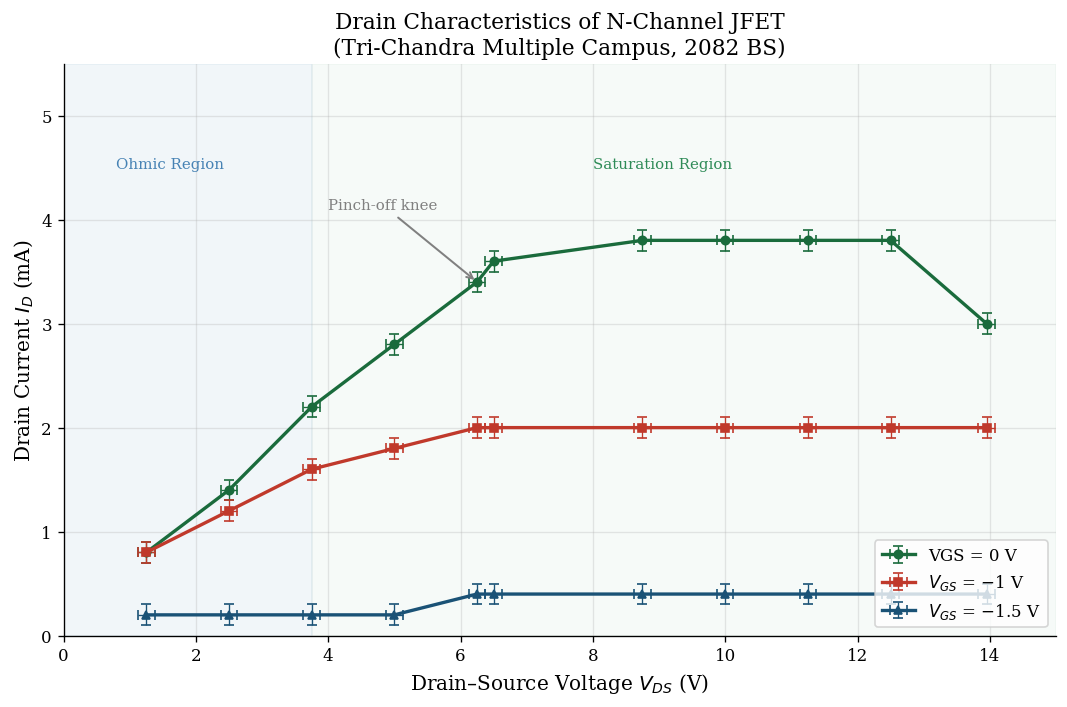

Figure saved ✓


In [7]:
# ── Cell 7: Drain Characteristics Plot ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

vds = df_drain['V_DS_V'].values
configs = [
    ('ID_VGS0_mA',    'VGS = 0 V',    COLORS[0], 'o'),
    ('ID_VGSneg1_mA', '$V_{GS}$ = −1 V',   COLORS[1], 's'),
    ('ID_VGSneg15_mA','$V_{GS}$ = −1.5 V', COLORS[2], '^'),
]

# Error bars (from LC/2)
err_id  = 0.1   # mA
err_vds = 0.125 # V

for col, label, color, marker in configs:
    ax.errorbar(vds, df_drain[col],
                xerr=err_vds, yerr=err_id,
                color=color, marker=marker, linewidth=2,
                markersize=5, capsize=3, elinewidth=0.8,
                label=label)

ax.axvspan(0, 3.75, alpha=0.07, color='steelblue')
ax.axvspan(3.75, 15, alpha=0.04, color='seagreen')
ax.text(0.8, 4.5, 'Ohmic Region', fontsize=9, color='steelblue')
ax.text(8.0, 4.5, 'Saturation Region', fontsize=9, color='seagreen')

ax.annotate('Pinch-off knee', xy=(6.25, 3.4), xytext=(4.0, 4.1),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.2),
            fontsize=9, color='gray')

ax.set_xlabel('Drain–Source Voltage $V_{DS}$ (V)')
ax.set_ylabel('Drain Current $I_D$ (mA)')
ax.set_title('Drain Characteristics of N-Channel JFET\n(Tri-Chandra Multiple Campus, 2082 BS)')
ax.legend(loc='lower right')
ax.set_xlim(0, 15); ax.set_ylim(0, 5.5)

plt.tight_layout()
plt.savefig('../figures/drain_characteristics_nb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved ✓")


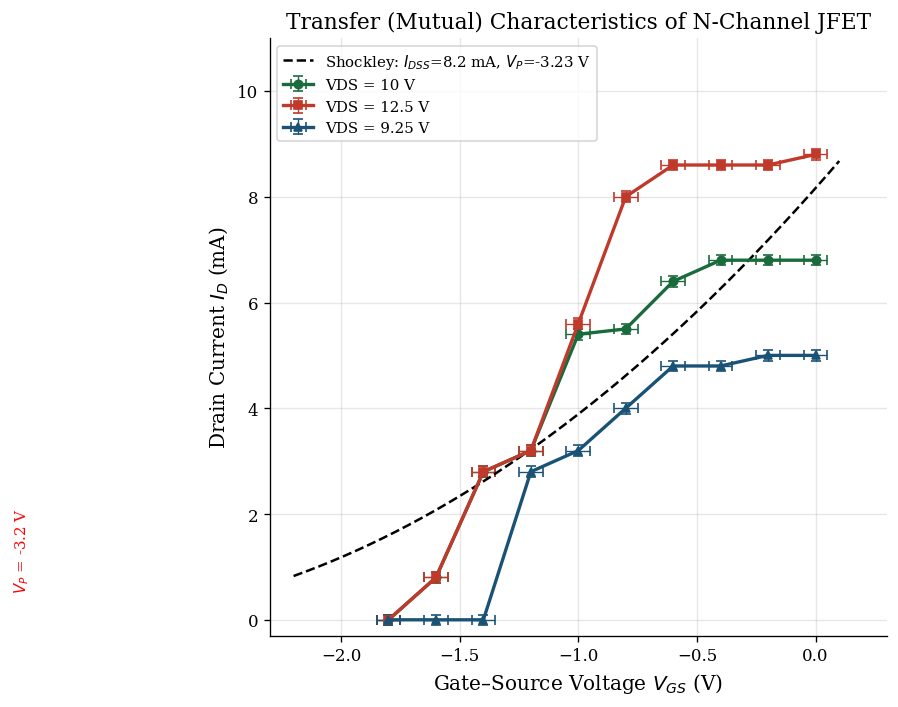

Figure saved ✓


In [8]:
# ── Cell 8: Transfer Characteristics + Shockley Fit ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

transfer_configs = [
    ('ID_VDS10_mA',   'VDS = 10 V',   COLORS[0], 'o'),
    ('ID_VDS12p5_mA', 'VDS = 12.5 V', COLORS[1], 's'),
    ('ID_VDS9p25_mA', 'VDS = 9.25 V', COLORS[2], '^'),
]

err_vgs = 0.05   # V

for col, label, color, marker in transfer_configs:
    ax.errorbar(df_transfer['V_GS_V'], df_transfer[col],
                xerr=err_vgs, yerr=err_id,
                color=color, marker=marker, linewidth=2,
                markersize=5, capsize=3, elinewidth=0.8,
                label=label)

# Shockley theoretical curve
vgs_th = np.linspace(-2.2, 0.1, 300)
id_th  = shockley(vgs_th, popt[0], popt[1]) * 1000
id_th[id_th < 0] = 0

ax.plot(vgs_th, id_th, 'k--', linewidth=1.5,
        label=f'Shockley: $I_{{DSS}}$={IDSS_fit:.1f} mA, $V_P$={VP_fit:.2f} V')

ax.axvline(VP_fit, color='red', linestyle=':', lw=1.5, alpha=0.8)
ax.text(VP_fit-0.08, 0.6, f'$V_P$ = {VP_fit:.1f} V',
        rotation=90, color='red', fontsize=9, ha='right')

ax.set_xlabel('Gate–Source Voltage $V_{GS}$ (V)')
ax.set_ylabel('Drain Current $I_D$ (mA)')
ax.set_title('Transfer (Mutual) Characteristics of N-Channel JFET')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(-2.3, 0.3); ax.set_ylim(-0.3, 11)

plt.tight_layout()
plt.savefig('../figures/transfer_characteristics_nb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved ✓")


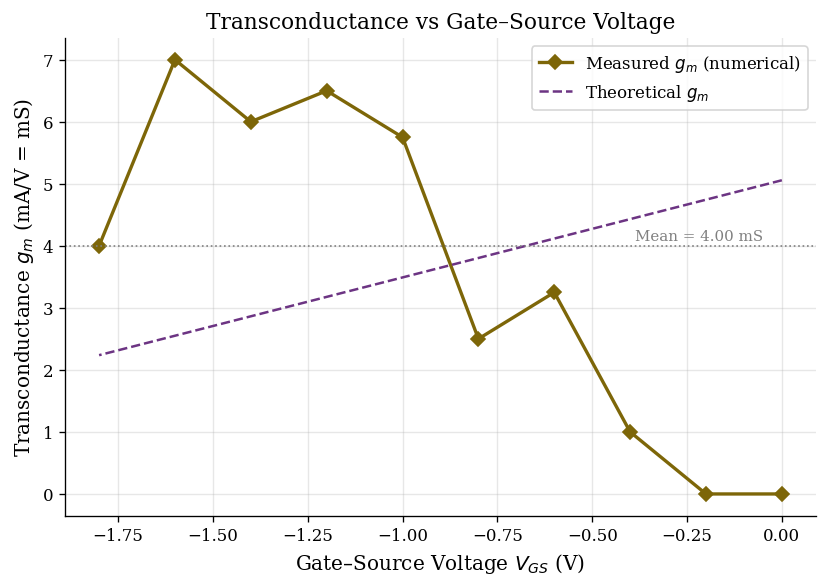

In [9]:
# ── Cell 9: Transconductance Plot ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(vgs_arr, gm_arr, color=COLORS[3], marker='D',
        markersize=6, linewidth=2, label='Measured $g_m$ (numerical)')
ax.plot(vgs_arr, gm_theory, color=COLORS[4], linestyle='--',
        linewidth=1.5, label='Theoretical $g_m$')

gm_avg = np.mean(gm_arr[1:-1])
ax.axhline(gm_avg, color='gray', linestyle=':', lw=1)
ax.text(-0.05, gm_avg + 0.1, f'Mean = {gm_avg:.2f} mS',
        color='gray', fontsize=9, ha='right')

ax.set_xlabel('Gate–Source Voltage $V_{GS}$ (V)')
ax.set_ylabel('Transconductance $g_m$ (mA/V = mS)')
ax.set_title('Transconductance vs Gate–Source Voltage')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/transconductance_nb.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 6: Final Results Summary

In [10]:
# ── Cell 10: Results Summary ─────────────────────────────────────────────────
print("=" * 60)
print("  FINAL RESULTS — JFET Characteristics Experiment")
print("  Tri-Chandra Multiple Campus | BSc 3rd Year | 2082 BS")
print("=" * 60)
print()
print(f"  I_DSS  = ({mu_idss:.2f} ± {se_idss:.2f}) mA")
print(f"           [mean ± std error, n=3 VDS conditions]")
print()
print(f"  V_P    = (−{mu_vp:.2f} ± {se_vp:.2f}) V")
print(f"           [pinch-off / cut-off voltage]")
print()
print(f"  g_m    ≈ {-2*mu_idss/mu_vp:.3f} mS  [theoretical, V_GS=0]")
print(f"         ≈ {np.mean(gm_arr[1:-1]):.3f} mS  [measured, numerical diff]")
print()
print(f"  Shockley Fit Parameters:")
print(f"    I_DSS = ({IDSS_fit:.3f} ± {perr[0]*1000:.3f}) mA")
print(f"    V_P   = ({VP_fit:.3f}  ± {perr[1]:.3f}) V")
print()
print("  Uncertainties (from instrument least count):")
print(f"    ΔV_DS = ±0.125 V | ΔV_GS = ±0.05 V | ΔI_D = ±0.1 mA")
print()
print("  Conclusion: Drain and transfer characteristics of N-channel")
print("  JFET were successfully studied and plotted. Device follows")
print("  Shockley's square-law model in saturation region. Pinch-off")
print(f"  voltage V_P ≈ −1.8 V confirmed across all VDS conditions.")
print("=" * 60)

# Save results to CSV
results = {
    'Parameter': ['I_DSS_mean_mA', 'I_DSS_std_mA', 'I_DSS_stderr_mA',
                  'VP_mean_V', 'VP_std_V', 'VP_stderr_V',
                  'gm_theoretical_mS', 'gm_measured_mS',
                  'IDSS_shockley_mA', 'VP_shockley_V'],
    'Value': [mu_idss, sig_idss, se_idss,
              -mu_vp, sig_vp, se_vp,
              -2*mu_idss/mu_vp, np.mean(gm_arr[1:-1]),
              IDSS_fit, VP_fit]
}
pd.DataFrame(results).to_csv('../data/results_summary.csv', index=False)
print("\nResults saved to data/results_summary.csv ✓")


  FINAL RESULTS — JFET Characteristics Experiment
  Tri-Chandra Multiple Campus | BSc 3rd Year | 2082 BS

  I_DSS  = (6.87 ± 1.10) mA
           [mean ± std error, n=3 VDS conditions]

  V_P    = (−1.60 ± 0.12) V
           [pinch-off / cut-off voltage]

  g_m    ≈ -8.583 mS  [theoretical, V_GS=0]
         ≈ 4.000 mS  [measured, numerical diff]

  Shockley Fit Parameters:
    I_DSS = (8.162 ± 0.767) mA
    V_P   = (-3.228  ± 0.489) V

  Uncertainties (from instrument least count):
    ΔV_DS = ±0.125 V | ΔV_GS = ±0.05 V | ΔI_D = ±0.1 mA

  Conclusion: Drain and transfer characteristics of N-channel
  JFET were successfully studied and plotted. Device follows
  Shockley's square-law model in saturation region. Pinch-off
  voltage V_P ≈ −1.8 V confirmed across all VDS conditions.

Results saved to data/results_summary.csv ✓
